# Weather Prediction


### Data Preprocessing


In [104]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
data = pd.read_csv('data/whether.csv')
input_cols = ['MinTemp', 'MaxTemp', 'Rainfall','WindGustDir','WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am','Temp3pm','RainToday']
numerical_cols = ['MinTemp', 'MaxTemp', 'Rainfall','WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Cloud9am', 'Cloud3pm']
categorical_cols = ['WindGustDir','WindDir9am', 'WindDir3pm','RainToday']
target_col = 'RainTomorrow'
scaler = MinMaxScaler().fit(data[numerical_cols])
data[numerical_cols] = scaler.transform(data[numerical_cols])
data.dropna(inplace=True)
encoder = OneHotEncoder(handle_unknown='ignore',sparse_output=False).fit(data[categorical_cols])
encoded_cols = encoder.get_feature_names_out(categorical_cols)
data[encoded_cols] = encoder.transform(data[categorical_cols])
X_train, X_test, Y_train, Y_test = train_test_split(data[numerical_cols+list(encoded_cols)], data[target_col], test_size=0.2, random_state=42)

### Model creation and prediction

In [105]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(solver='liblinear').fit(X_train, Y_train)

In [106]:
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
def predict_and_plot(input_data,target):
    global model
    predictions = model.predict(input_data)
    print(f"Accuracy of the prediction:{accuracy_score(target, predictions)*100:.2f}%")
    cf = confusion_matrix(target, predictions, normalize='true')
    sns.heatmap(cf, annot=True)
    plt.show()

Accuracy of the prediction:84.93%


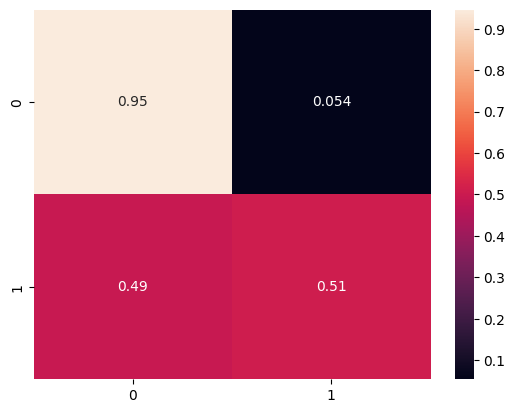

In [107]:
predict_and_plot(X_test, Y_test)

### Saving and loading a ML model back

In [108]:
aussie_rain = {'model': model, 'scaler': scaler, 'encoder': encoder,
               'input_cols': input_cols, 'target_col': target_col, 'numeric_cols': numerical_cols,
               'categorical_cols': categorical_cols, 'encoded_cols': encoded_cols}

In [109]:
import joblib
joblib.dump(aussie_rain, "C:/Users/DELL/Desktop/Machine Learning/ML from youtube/joblibs models/Ausie_whethers.joblib")

['C:/Users/DELL/Desktop/Machine Learning/ML from youtube/joblibs models/Ausie_whethers.joblib']

In [110]:
aussie_rain2 = joblib.load("C:/Users/DELL/Desktop/Machine Learning/ML from youtube/joblibs models/Ausie_whethers.joblib")

In [153]:
def predict_input(single_input):
    input_df = pd.DataFrame([single_input])
    scaled_df = pd.DataFrame(scaler.transform(input_df[numerical_cols]))
    encoded_df = pd.DataFrame(encoder.transform(input_df[categorical_cols]))
    final_df = pd.concat([scaled_df, encoded_df], axis=1)
    pred = model.predict(final_df)
    prob = model.predict_proba(final_df)
    
    print(f"Will it rain?: {pred.tolist()[0]}")
    print(f"Chances of rain: {((prob).tolist()[0][1])*100:.2f}%")

In [154]:
import numpy as np
predict_input({'Date': '2021-06-19',
             'Location': 'Launceston',
             'MinTemp': 23.2,
             'MaxTemp': 33.2,
             'Rainfall': 10.2,
             'Evaporation': 4.2,
             'Sunshine': np.nan,
             'WindGustDir': 'NNW',
             'WindGustSpeed': 52.0,
             'WindDir9am': 'NW',
             'WindDir3pm': 'NNE',
             'WindSpeed9am': 13.0,
             'WindSpeed3pm': 20.0,
             'Humidity9am': 89.0,
             'Humidity3pm': 58.0,
             'Pressure9am': 1004.8,
             'Pressure3pm': 1001.5,
             'Cloud9am': 8.0,
             'Cloud3pm': 5.0,
             'Temp9am': 25.7,
             'Temp3pm': 33.0,
             'RainToday': 'Yes'})

Will it rain?: Yes
Chances of rain: 67.30%


c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
